In [1]:
# ── Cell 1 — imports, path & reload ───────────────────────────────────────────
import sys, os, importlib, warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../../model'))
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('../.'))

F_N monthly means: [4.1  5.39 4.37 2.79 3.44 2.01 2.4  1.87 1.47 1.54 1.23 1.8 ]  cycle mean = 2.7
run reached t=1825 d | finite N: True | yr-5 mean mcs=2.70 µm, N=1.48


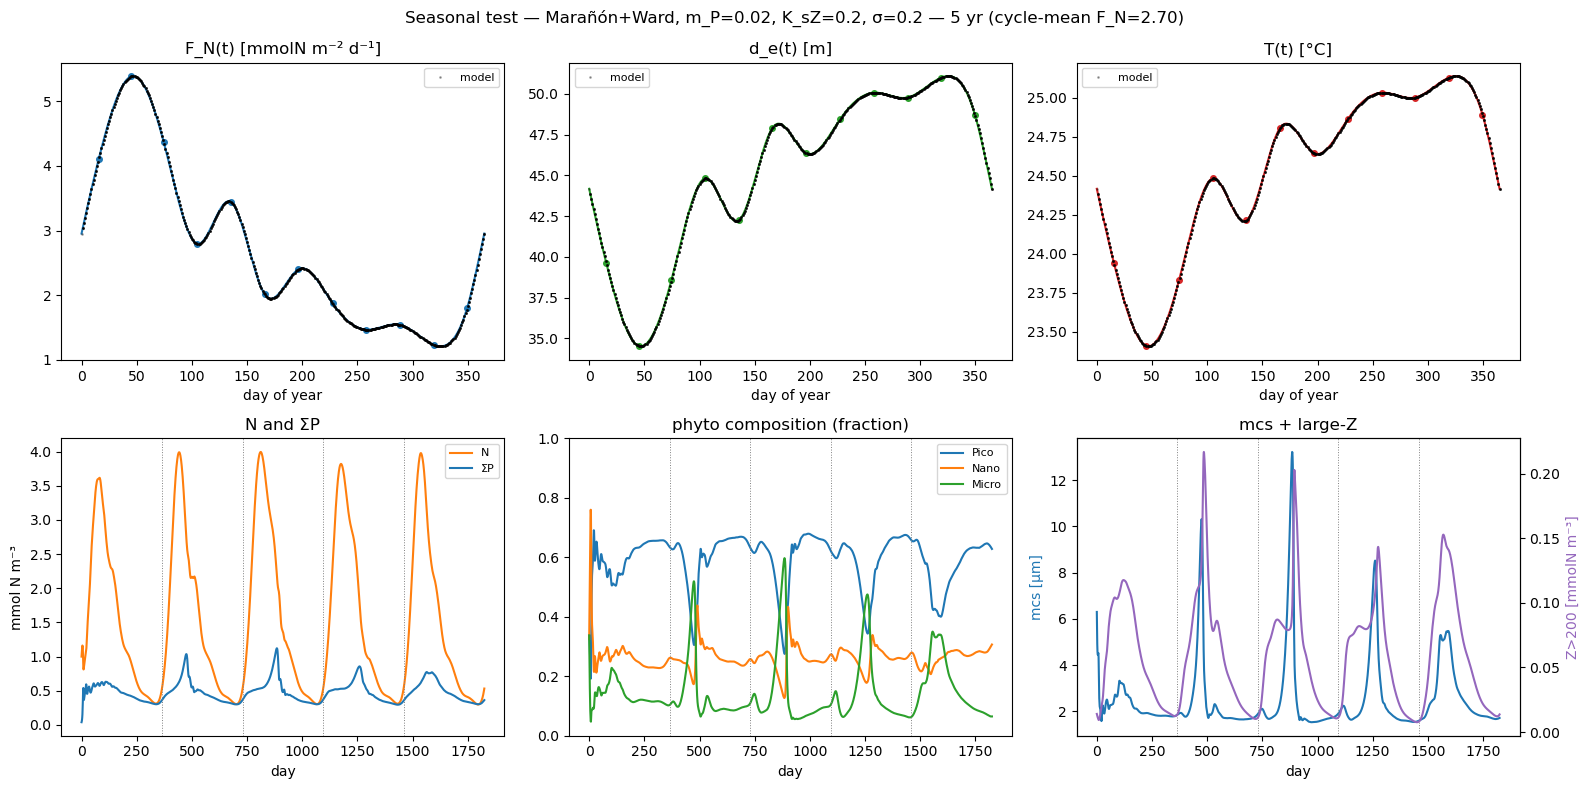

In [3]:
# ── TEST RUN: seasonal forcing — obs climatology + model output ──────────────
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import scipy.interpolate as intrp
import xso, cariaco_obs as co, baseline_r0_setups as brs
import parscan_utils_extended as pue, baseline_r0_seasonal_setups as sss
from baseline_r0_seasonal_comps import _MID_MONTH_DOY
import importlib
for m in (co, brs, pue): importlib.reload(m)
importlib.reload(sss)

# --- 1. obs F_N calendar-month climatology (full-data composite, means) ---
_, _, _, mdf, _ = co.load_cariaco_targets('all', months='available', agg='mean')
mdf = mdf.copy()
mdf['cal_month'] = pd.to_datetime(mdf['date']).dt.month
fn_clim = (mdf.groupby('cal_month')['FN_mmolN_m2_d'].mean()
              .reindex(range(1, 13)).interpolate().bfill().ffill().to_numpy())
print("F_N monthly means:", np.round(fn_clim, 2), " cycle mean =", round(fn_clim.mean(), 2))

# --- cell-side forcing functions (same construction as SeasonalForcing) ---
def fn_of_t(t):
    x = np.concatenate([[0.0], _MID_MONTH_DOY, [sss.PERIOD]])
    wrap = (fn_clim[0] + fn_clim[-1]) / 2.0
    y = np.concatenate([[wrap], fn_clim, [wrap]])
    tck = intrp.splrep(x, y, per=True, k=sss.SPLINE_K, s=sss.SPLINE_S)
    return np.maximum(intrp.splev(np.mod(t, sss.PERIOD), tck), 0.0)
de_a, de_b, de_lo, de_hi = sss.DE_COEFFS
t_a,  t_b,  t_lo,  t_hi  = sss.T_COEFFS
de_of_t = lambda t: np.clip(de_a - de_b * fn_of_t(t), de_lo, de_hi)
T_of_t  = lambda t: np.clip(t_a  - t_b  * fn_of_t(t), t_lo,  t_hi)

# --- 2. build + run the seasonal model (top-combined params, Marañón+Ward) ---
esd    = brs.phyto_esd
mu_mar = np.where(esd <= 5.38, 0.33 * esd ** 0.57, 1.83 * esd ** -0.45)
ks_ward = 0.143 * esd ** 0.81
N_YEARS = 5
iv = sss.make_seasonal_input_vars(fn_clim, mu_max=mu_mar, halfsat=ks_ward, mP=0.02)
iv['Grazing'] = {**iv['Grazing'], 'KsZ': 0.20, 'sigma_log': 0.20}
time = np.arange(0.0, N_YEARS * 365.0 + 1.0, 1.0)
solver_kw = {**brs.IVP_SOLVER_KWARGS, 'instability_neg_threshold': -1e-3}

forc_vars = {'Forcing__fn_value', 'Forcing__de_value', 'Forcing__temperature_value'}
try:                                              # request the model's own forcing series
    setup = xso.setup(solver='solve_ivp', model=sss.model_baseline_seasonal, time=time,
                      input_vars=iv, output_vars=set(sss.SLIM_OUTPUT_VARS) | forc_vars,
                      solver_kwargs=solver_kw)
    has_forc = True
except Exception as e:                            # fall back if forcing-output naming differs
    print("[note] forcing output vars not stored:", e)
    setup = xso.setup(solver='solve_ivp', model=sss.model_baseline_seasonal, time=time,
                      input_vars=iv, output_vars=set(sss.SLIM_OUTPUT_VARS), solver_kwargs=solver_kw)
    has_forc = False

out = pue.run_single_point(sss.model_baseline_seasonal, setup, {})
t = out['time'].values

# --- derived state over time ---
# --- derived state over time ---
Pesd = out['phyto'].values
W = pue.compute_sieburth_weights(Pesd)                       # (3, n_phyto) Pico/Nano/Micro
Pv = out['Phytoplankton__biomass'].transpose('time', 'phyto').values   # (time, phyto)  <-- fix
bins = np.einsum('kp,tp->tk', W, Pv)
frac = bins / np.clip(bins.sum(1, keepdims=True), 1e-30, None)
geom = np.asarray(pue.CARIACO_PHYTO_BIN_GEOMEANS, float)
mcs_t = 10.0 ** (frac @ np.log10(geom))
sumP = Pv.sum(1)
N_t  = out['Nutrient__value'].values
Zg200 = out['Zooplankton__biomass'].where(out['zoo'] > 200.0, 0.0).sum('zoo').values
print(f"run reached t={t[-1]:.0f} d | finite N: {np.isfinite(N_t).all()} | "
      f"yr-5 mean mcs={np.nanmean(mcs_t[t >= 4*365]):.2f} µm, N={np.nanmean(N_t[t >= 4*365]):.2f}")

# --- 3. plot: forcings (one year) + output (full record) ---
fig, ax = plt.subplots(2, 3, figsize=(16, 8))
ty = np.linspace(0, 365, 366)
for a, f, lab, c in [(ax[0, 0], fn_of_t, 'F_N(t) [mmolN m⁻² d⁻¹]', 'C0'),
                     (ax[0, 1], de_of_t, 'd_e(t) [m]', 'C2'),
                     (ax[0, 2], T_of_t,  'T(t) [°C]', 'C3')]:
    a.plot(ty, f(ty), '-', color=c)
    a.plot(_MID_MONTH_DOY, (fn_clim if f is fn_of_t else f(_MID_MONTH_DOY)), 'o', color=c, ms=4)
    a.set_xlabel('day of year'); a.set_title(lab)
    if has_forc:
        key = {'F_N(t) [mmolN m⁻² d⁻¹]': 'Forcing__fn_value', 'd_e(t) [m]': 'Forcing__de_value',
               'T(t) [°C]': 'Forcing__temperature_value'}[lab]
        a.plot(np.mod(t, 365), out[key].values, '.', color='k', ms=2, alpha=0.3, label='model')
        a.legend(fontsize=8)

yrs = [365 * k for k in range(1, N_YEARS)]
ax[1, 0].plot(t, N_t, 'C1', label='N'); ax[1, 0].plot(t, sumP, 'C0', label='ΣP')
ax[1, 0].set_title('N and ΣP'); ax[1, 0].set_ylabel('mmol N m⁻³'); ax[1, 0].legend(fontsize=8)
for lab, col, c in [('Pico', 0, 'C0'), ('Nano', 1, 'C1'), ('Micro', 2, 'C2')]:
    ax[1, 1].plot(t, frac[:, col], color=c, label=lab)
ax[1, 1].set_title('phyto composition (fraction)'); ax[1, 1].set_ylim(0, 1); ax[1, 1].legend(fontsize=8)
ax[1, 2].plot(t, mcs_t, 'C0', label='mcs [µm]')
axb = ax[1, 2].twinx(); axb.plot(t, Zg200, 'C4', label='Z>200'); axb.set_ylabel('Z>200 [mmolN m⁻³]', color='C4')
ax[1, 2].set_title('mcs + large-Z'); ax[1, 2].set_ylabel('mcs [µm]', color='C0')
for a in ax[1, :]:
    a.set_xlabel('day'); [a.axvline(x, color='grey', ls=':', lw=0.7) for x in yrs]
fig.suptitle(f"Seasonal test — Marañón+Ward, m_P=0.02, K_sZ=0.2, σ=0.2 — {N_YEARS} yr "
             f"(cycle-mean F_N={fn_clim.mean():.2f})")
plt.tight_layout(); plt.show()

cycle-mean F_N=2.70 -> SS forcing d_e=45.2 m, T=24.52 °C

metric       obs   SS@mean  seas_yr5  yr5_min  yr5_max  seas/SS
mcs        2.421     2.027     2.697    1.608    5.478     1.33
Pico       0.580     0.608     0.571    0.400    0.659     0.94
Nano       0.268     0.276     0.264    0.207    0.307     0.96
Micro      0.152     0.116     0.165    0.064    0.350     1.42
ΣP         0.474     0.448     0.488    0.303    0.774     1.09
Z>200      0.055     0.047     0.064    0.008    0.153     1.36
N          1.218     1.050     1.480    0.299    3.978     1.41


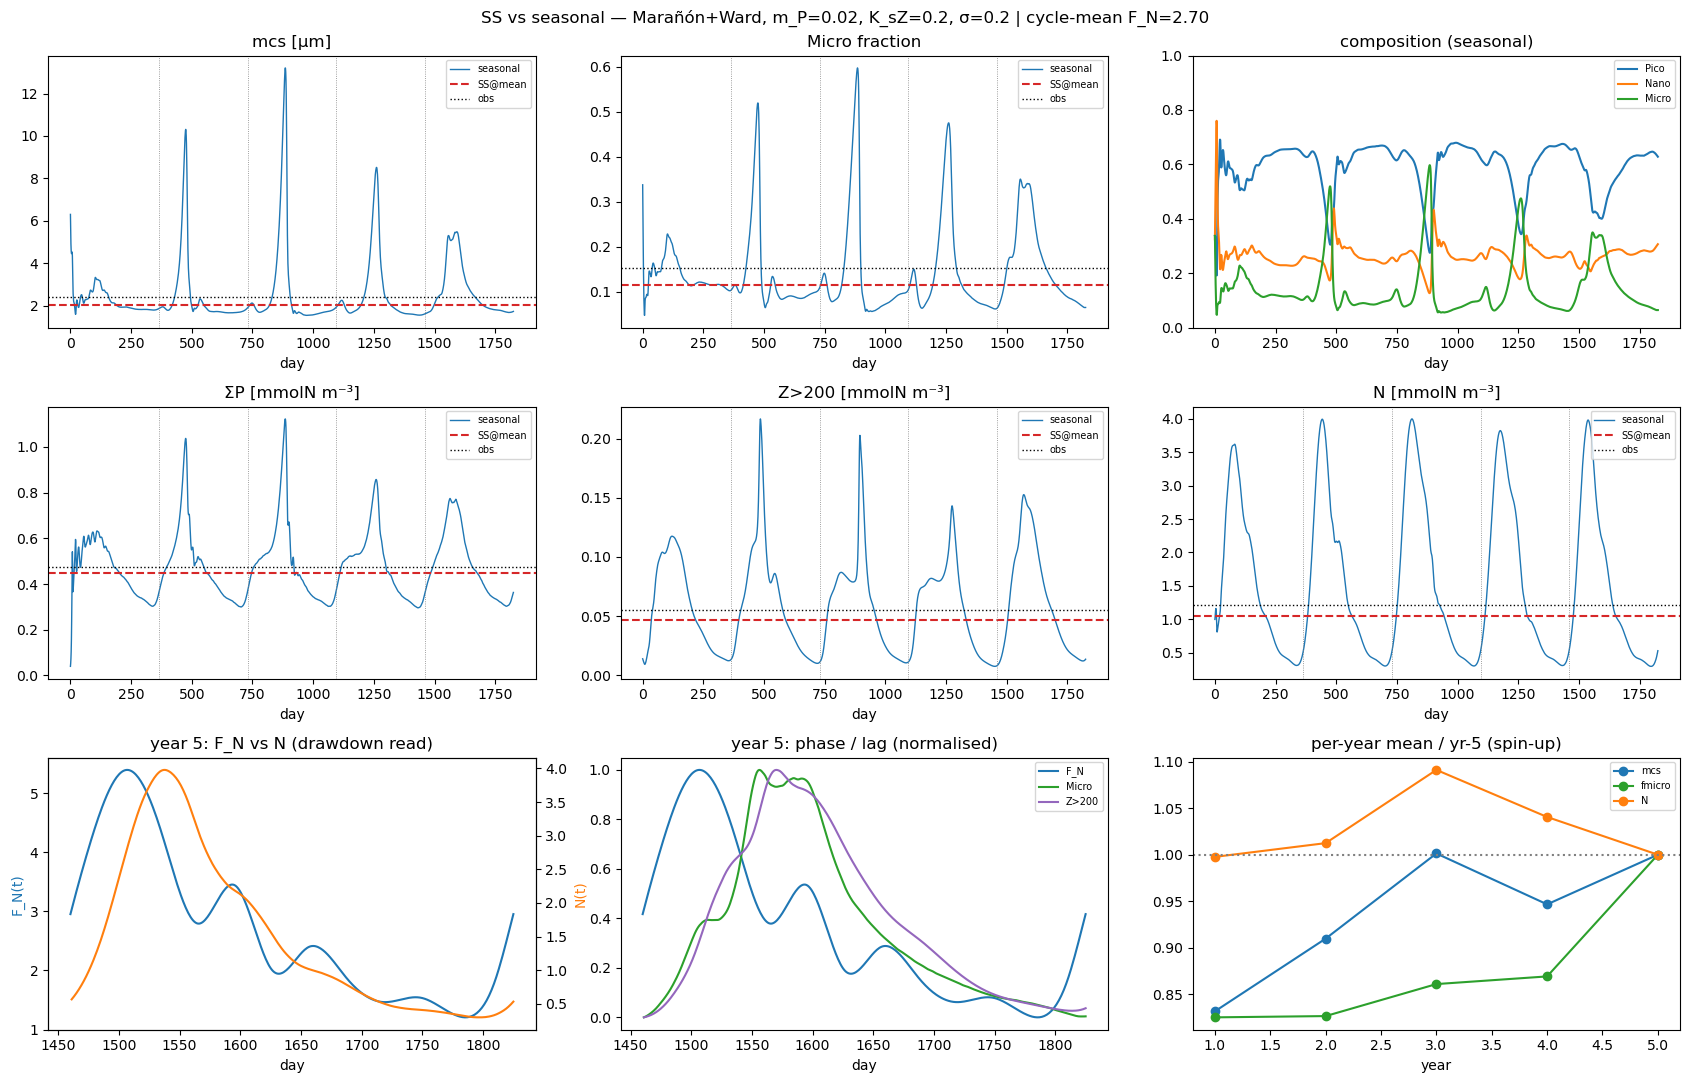

In [9]:
# ── SS vs SEASONAL — matched-mean comparison + diagnostics ───────────────────
import numpy as np, pandas as pd, matplotlib.pyplot as plt, json
import scipy.interpolate as intrp
import xso, cariaco_obs as co, baseline_r0_setups as brs
import parscan_utils_extended as pue, baseline_r0_seasonal_setups as sss
from baseline_r0_seasonal_comps import _MID_MONTH_DOY
import importlib
for m in (co, brs, pue): importlib.reload(m)
importlib.reload(sss)

# --- obs F_N climatology (composite, means) + obs reference medians ---
_, _, _, mdf, _ = co.load_cariaco_targets('all', months='available', agg='mean')
mdf = mdf.copy(); mdf['cal_month'] = pd.to_datetime(mdf['date']).dt.month
fn_clim = (mdf.groupby('cal_month')['FN_mmolN_m2_d'].mean()
              .reindex(range(1, 13)).interpolate().bfill().ffill().to_numpy())
_, _, _, mdf_h, _ = co.load_cariaco_targets('all', months='hplc', agg='median')
obs = pue.build_obs_refs(mdf_h)
op = np.array([obs['P_pico'], obs['P_nano'], obs['P_micro']]); ofrac = op / op.sum()
obs_row = {'mcs': obs['mcs'], 'fpico': ofrac[0], 'fnano': ofrac[1], 'fmicro': ofrac[2],
           'sumP': obs['sumP'], 'N': obs['N'], 'Zg200': obs['Z_gt200']}

# --- cell-side F_N(t) for plotting the forcing ---
def fn_of_t(t):
    x = np.concatenate([[0.0], _MID_MONTH_DOY, [sss.PERIOD]])
    wrap = (fn_clim[0] + fn_clim[-1]) / 2.0
    y = np.concatenate([[wrap], fn_clim, [wrap]])
    tck = intrp.splrep(x, y, per=True, k=sss.SPLINE_K, s=sss.SPLINE_S)
    return np.maximum(intrp.splev(np.mod(t, sss.PERIOD), tck), 0.0)

# --- construct (top-combined, Marañón+Ward) ---
esd = brs.phyto_esd
mu_mar = np.where(esd <= 5.38, 0.33 * esd ** 0.57, 1.83 * esd ** -0.45)
ks_ward = 0.143 * esd ** 0.81
PARAMS = dict(mP=0.02, KsZ=0.20, sig=0.20)
solver_kw = {**brs.IVP_SOLVER_KWARGS, 'instability_neg_threshold': -1e-3}
N_YEARS = 5

# --- run SEASONAL ---
iv = sss.make_seasonal_input_vars(fn_clim, mu_max=mu_mar, halfsat=ks_ward, mP=PARAMS['mP'])
iv['Grazing'] = {**iv['Grazing'], 'KsZ': PARAMS['KsZ'], 'sigma_log': PARAMS['sig']}
seas_setup = xso.setup(solver='solve_ivp', model=sss.model_baseline_seasonal,
                       time=np.arange(0.0, N_YEARS * 365.0 + 1.0, 1.0),
                       input_vars=iv, output_vars=set(sss.SLIM_OUTPUT_VARS), solver_kwargs=solver_kw)
seas = pue.run_single_point(sss.model_baseline_seasonal, seas_setup, {})

# --- run SS at the cycle mean (same construct, d_e/T from the regression) ---
FN_bar = float(fn_clim.mean())
de_a, de_b, de_lo, de_hi = sss.DE_COEFFS; t_a, t_b, t_lo, t_hi = sss.T_COEFFS
de_bar = float(np.clip(de_a - de_b * FN_bar, de_lo, de_hi))
T_bar  = float(np.clip(t_a  - t_b  * FN_bar, t_lo,  t_hi))
ss_over = {'Inflow__FN': FN_bar, 'Inflow__de': de_bar, 'Temperature__value': T_bar,
           'Growth__mu_max': mu_mar, 'Growth__halfsat': ks_ward,
           'PhytoMortality__rate': PARAMS['mP'], 'Grazing__KsZ': PARAMS['KsZ'],
           'Grazing__sigma_log': PARAMS['sig'], 'Core__solver_kwargs': json.dumps(solver_kw)}
ss = pue.run_single_point(brs.model_baseline, brs.setup_baseline_slim, {}, ss_over)
print(f"cycle-mean F_N={FN_bar:.2f} -> SS forcing d_e={de_bar:.1f} m, T={T_bar:.2f} °C")

# --- metric trajectories (identical definitions for both) ---
def traj(o):
    P = o['Phytoplankton__biomass'].transpose('time', 'phyto').values
    W = pue.compute_sieburth_weights(o['phyto'].values)
    b = np.einsum('kp,tp->tk', W, P); fr = b / np.clip(b.sum(1, keepdims=True), 1e-30, None)
    geom = np.asarray(pue.CARIACO_PHYTO_BIN_GEOMEANS, float)
    return dict(t=o['time'].values, mcs=10.0 ** (fr @ np.log10(geom)),
                fpico=fr[:, 0], fnano=fr[:, 1], fmicro=fr[:, 2], sumP=P.sum(1),
                N=o['Nutrient__value'].values,
                Zg200=o['Zooplankton__biomass'].where(o['zoo'] > 200.0, 0.0).sum('zoo').values)
S, M = traj(ss), traj(seas)
KEYS = ['mcs', 'fpico', 'fnano', 'fmicro', 'sumP', 'Zg200', 'N']
LAB  = {'mcs': 'mcs', 'fpico': 'Pico', 'fnano': 'Nano', 'fmicro': 'Micro',
        'sumP': 'ΣP', 'Zg200': 'Z>200', 'N': 'N'}
ss_mask = S['t'] >= S['t'][-1] - 1000          # SS tail-mean window
y5 = M['t'] >= (N_YEARS - 1) * 365             # seasonal year-5 window
ssv  = {k: float(np.nanmean(S[k][ss_mask])) for k in KEYS}
seav = {k: (float(np.nanmean(M[k][y5])), float(np.nanmin(M[k][y5])), float(np.nanmax(M[k][y5]))) for k in KEYS}

# --- comparison table ---
print(f"\n{'metric':7}{'obs':>9}{'SS@mean':>10}{'seas_yr5':>10}{'yr5_min':>9}{'yr5_max':>9}{'seas/SS':>9}")
for k in KEYS:
    sm, smn, smx = seav[k]; r = sm / ssv[k] if ssv[k] else np.nan
    print(f"{LAB[k]:7}{obs_row[k]:9.3f}{ssv[k]:10.3f}{sm:10.3f}{smn:9.3f}{smx:9.3f}{r:9.2f}")

# --- diagnostics figure ---
fig, ax = plt.subplots(3, 3, figsize=(17, 11))
def overlay(a, key, title, obskey=None):
    a.plot(M['t'], M[key], 'C0', lw=1, label='seasonal')
    a.axhline(ssv[key], color='C3', ls='--', lw=1.5, label='SS@mean')
    if obskey is not None and np.isfinite(obs_row[obskey]):
        a.axhline(obs_row[obskey], color='k', ls=':', lw=1, label='obs')
    for yb in [365 * k for k in range(1, N_YEARS)]: a.axvline(yb, color='grey', ls=':', lw=0.6)
    a.set_title(title); a.set_xlabel('day'); a.legend(fontsize=7)
overlay(ax[0, 0], 'mcs', 'mcs [µm]', 'mcs')
overlay(ax[0, 1], 'fmicro', 'Micro fraction', 'fmicro')
ax[0, 2].plot(M['t'], M['fpico'], 'C0', label='Pico'); ax[0, 2].plot(M['t'], M['fnano'], 'C1', label='Nano')
ax[0, 2].plot(M['t'], M['fmicro'], 'C2', label='Micro'); ax[0, 2].set_ylim(0, 1)
ax[0, 2].set_title('composition (seasonal)'); ax[0, 2].set_xlabel('day'); ax[0, 2].legend(fontsize=7)
overlay(ax[1, 0], 'sumP', 'ΣP [mmolN m⁻³]', 'sumP')
overlay(ax[1, 1], 'Zg200', 'Z>200 [mmolN m⁻³]', 'Zg200')
overlay(ax[1, 2], 'N', 'N [mmolN m⁻³]', 'N')

ty = np.linspace(4 * 365, 5 * 365, 366)        # year 5, drawdown read
a = ax[2, 0]; a.plot(ty, fn_of_t(ty), 'C0'); a.set_ylabel('F_N(t)', color='C0')
ab = a.twinx(); ab.plot(M['t'][y5], M['N'][y5], 'C1'); ab.set_ylabel('N(t)', color='C1')
a.set_title('year 5: F_N vs N (drawdown read)'); a.set_xlabel('day')

a = ax[2, 1]; norm = lambda v: (v - np.nanmin(v)) / (np.nanmax(v) - np.nanmin(v) + 1e-12)
a.plot(ty, norm(fn_of_t(ty)), 'C0', label='F_N'); a.plot(M['t'][y5], norm(M['fmicro'][y5]), 'C2', label='Micro')
a.plot(M['t'][y5], norm(M['Zg200'][y5]), 'C4', label='Z>200')
a.set_title('year 5: phase / lag (normalised)'); a.set_xlabel('day'); a.legend(fontsize=7)

a = ax[2, 2]; yrs = np.arange(1, N_YEARS + 1)
for key, c in [('mcs', 'C0'), ('fmicro', 'C2'), ('N', 'C1')]:
    ym = np.array([np.nanmean(M[key][(M['t'] >= (y - 1) * 365) & (M['t'] < y * 365)]) for y in yrs])
    a.plot(yrs, ym / ym[-1], '-o', color=c, label=key)
a.axhline(1.0, color='grey', ls=':'); a.set_title('per-year mean / yr-5 (spin-up)')
a.set_xlabel('year'); a.legend(fontsize=7)
fig.suptitle(f"SS vs seasonal — Marañón+Ward, m_P={PARAMS['mP']}, K_sZ={PARAMS['KsZ']}, σ={PARAMS['sig']}"
             f" | cycle-mean F_N={FN_bar:.2f}")
plt.tight_layout(); plt.show()

cycle-mean F_N=2.70 | 120-yr run, stats over yrs 10–120

metric       obs   SS@mean   LRmean     ±SD  CVinter   LR/SS
mcs        2.421     2.027    2.857   0.270     0.09    1.41
Pico       0.580     0.608    0.570   0.016     0.03    0.94
Nano       0.268     0.276    0.263   0.008     0.03    0.95
Micro      0.152     0.116    0.167   0.023     0.14    1.44
ΣP         0.474     0.448    0.498   0.016     0.03    1.11
Z>200      0.055     0.047    0.050   0.002     0.04    1.05
N          1.218     1.050    1.545   0.071     0.05    1.47

dominant interannual period (Micro yearly-mean): 36.7 yr


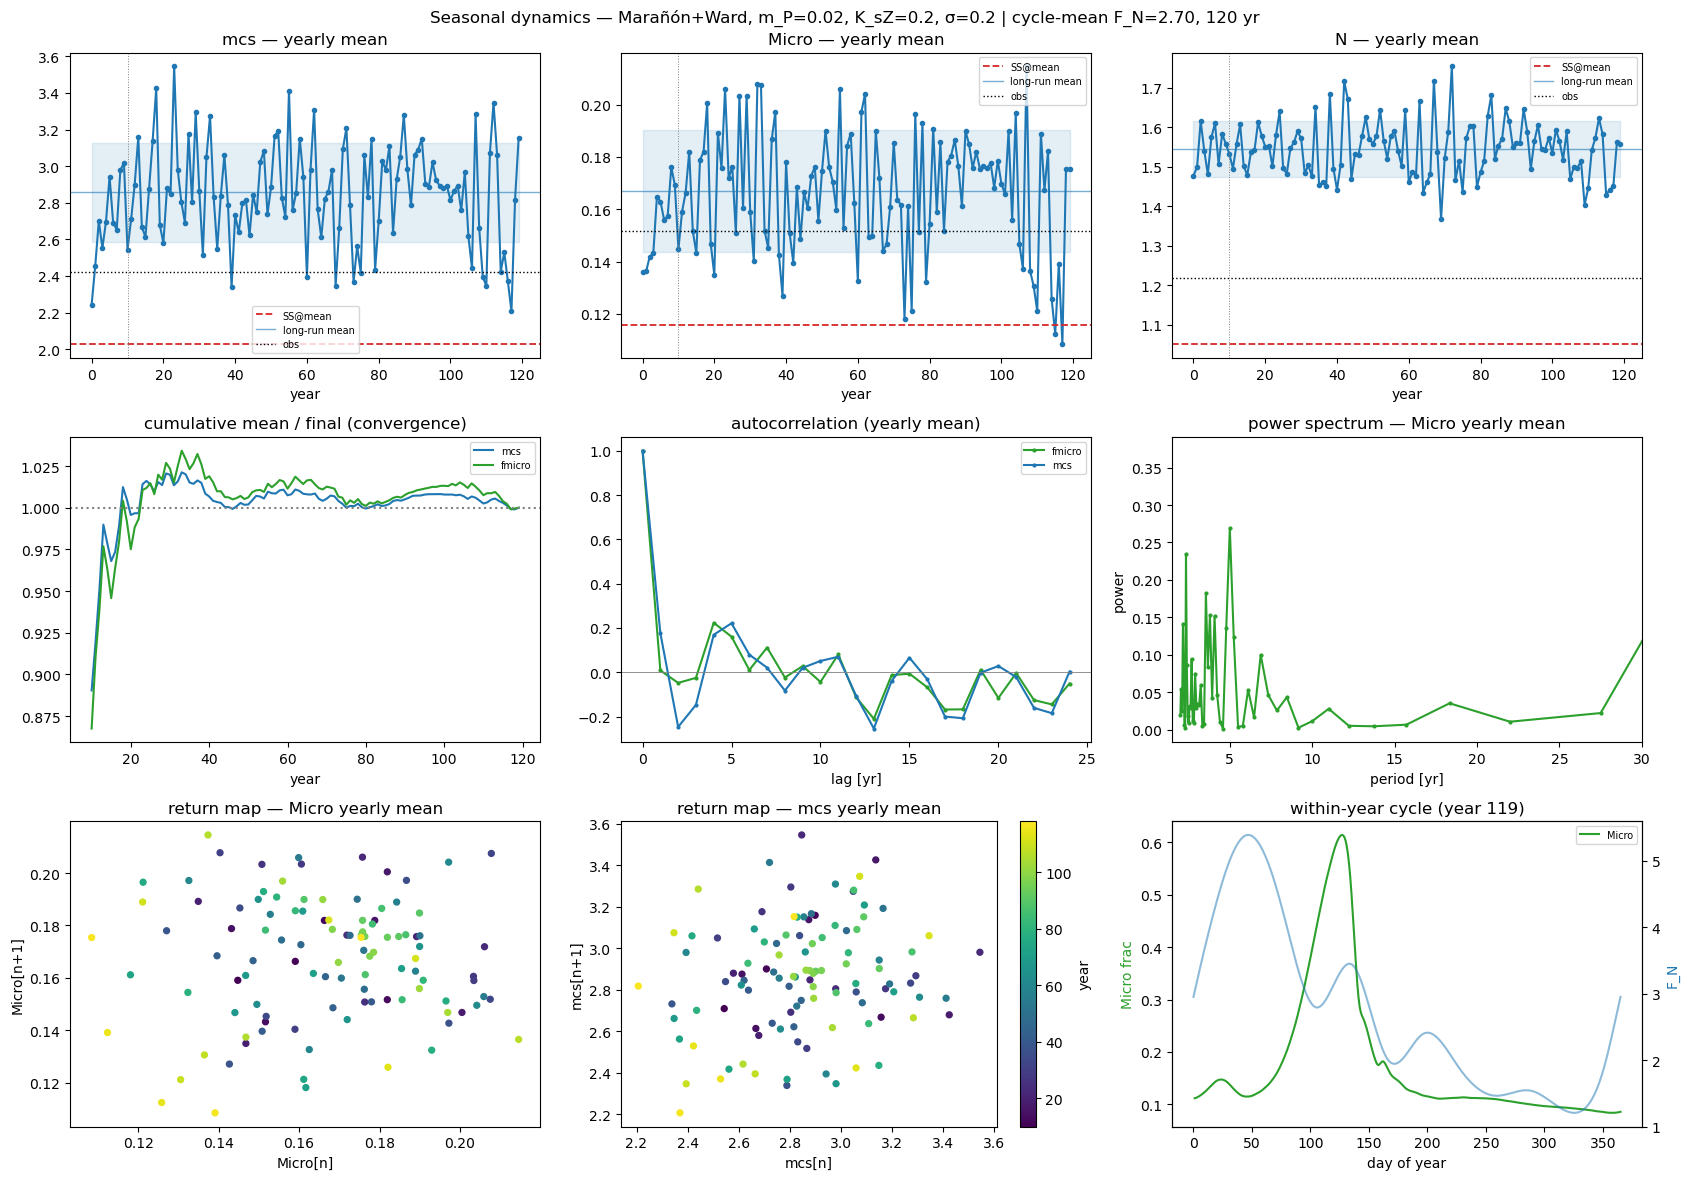


metric   LR/obs  yr-min  yr-max   ACF1   ACF2
mcs        1.18   2.207   3.545   0.18  -0.25
Pico       0.98   0.528   0.612   0.00  -0.04
Nano       0.98   0.247   0.283   0.04  -0.04
Micro      1.10   0.108   0.215   0.01  -0.05
ΣP         1.05   0.458   0.538   0.25  -0.29
Z>200      0.90   0.044   0.058   0.30   0.26
N          1.27   1.367   1.754   0.11  -0.26

cumulative Micro LR-mean by year: {20: 0.1655, 30: 0.1714, 40: 0.1697, 50: 0.1677, 120: 0.1669}    (flat => converged)
top-3 Micro interannual periods [yr]: [36.7, 5.0, 2.3]
interannual: Micro CV=0.14, mcs CV=0.09, ACF1(Micro)=0.01  (~0 => quasiperiodic/chaotic, ~±1 => periodic)


In [11]:
# ── SEASONAL DYNAMICS — long-run mean, interannual evolution, periodicity ─────
import numpy as np, pandas as pd, matplotlib.pyplot as plt, json
import scipy.interpolate as intrp
import xso, cariaco_obs as co, baseline_r0_setups as brs
import parscan_utils_extended as pue, baseline_r0_seasonal_setups as sss
from baseline_r0_seasonal_comps import _MID_MONTH_DOY
import importlib
for m in (co, brs, pue): importlib.reload(m)
importlib.reload(sss)

N_YEARS, SPINUP_YEARS = 120, 10          # bump N_YEARS for finer spectra; SPINUP = transient to drop

# --- obs climatology + obs reference medians ---
_, _, _, mdf, _ = co.load_cariaco_targets('all', months='available', agg='mean')
mdf = mdf.copy(); mdf['cal_month'] = pd.to_datetime(mdf['date']).dt.month
fn_clim = (mdf.groupby('cal_month')['FN_mmolN_m2_d'].mean()
              .reindex(range(1, 13)).interpolate().bfill().ffill().to_numpy())
_, _, _, mdf_h, _ = co.load_cariaco_targets('all', months='hplc', agg='median')
obs = pue.build_obs_refs(mdf_h); op = np.array([obs['P_pico'], obs['P_nano'], obs['P_micro']])
obs_row = {'mcs': obs['mcs'], 'fpico': op[0] / op.sum(), 'fnano': op[1] / op.sum(),
           'fmicro': op[2] / op.sum(), 'sumP': obs['sumP'], 'Zg200': obs['Z_gt200'], 'N': obs['N']}

def fn_of_t(t):
    x = np.concatenate([[0.0], _MID_MONTH_DOY, [sss.PERIOD]]); wrap = (fn_clim[0] + fn_clim[-1]) / 2
    y = np.concatenate([[wrap], fn_clim, [wrap]])
    return np.maximum(intrp.splev(np.mod(t, sss.PERIOD),
                                  intrp.splrep(x, y, per=True, k=sss.SPLINE_K, s=sss.SPLINE_S)), 0.0)

# --- construct + runs ---
esd = brs.phyto_esd
mu_mar = np.where(esd <= 5.38, 0.33 * esd ** 0.57, 1.83 * esd ** -0.45); ks_ward = 0.143 * esd ** 0.81
P = dict(mP=0.02, KsZ=0.20, sig=0.20); solver_kw = {**brs.IVP_SOLVER_KWARGS, 'instability_neg_threshold': -1e-3}

iv = sss.make_seasonal_input_vars(fn_clim, mu_max=mu_mar, halfsat=ks_ward, mP=P['mP'])
iv['Grazing'] = {**iv['Grazing'], 'KsZ': P['KsZ'], 'sigma_log': P['sig']}
seas_setup = xso.setup(solver='solve_ivp', model=sss.model_baseline_seasonal,
                       time=np.arange(0.0, N_YEARS * 365.0 + 1.0, 1.0),
                       input_vars=iv, output_vars=set(sss.SLIM_OUTPUT_VARS), solver_kwargs=solver_kw)
seas = pue.run_single_point(sss.model_baseline_seasonal, seas_setup, {})

FN_bar = float(fn_clim.mean()); de_a, de_b, de_lo, de_hi = sss.DE_COEFFS; t_a, t_b, t_lo, t_hi = sss.T_COEFFS
de_bar = float(np.clip(de_a - de_b * FN_bar, de_lo, de_hi)); T_bar = float(np.clip(t_a - t_b * FN_bar, t_lo, t_hi))
ss = pue.run_single_point(brs.model_baseline, brs.setup_baseline_slim, {},
        {'Inflow__FN': FN_bar, 'Inflow__de': de_bar, 'Temperature__value': T_bar,
         'Growth__mu_max': mu_mar, 'Growth__halfsat': ks_ward, 'PhytoMortality__rate': P['mP'],
         'Grazing__KsZ': P['KsZ'], 'Grazing__sigma_log': P['sig'], 'Core__solver_kwargs': json.dumps(solver_kw)})

def traj(o):
    Pb = o['Phytoplankton__biomass'].transpose('time', 'phyto').values
    W = pue.compute_sieburth_weights(o['phyto'].values)
    b = np.einsum('kp,tp->tk', W, Pb); fr = b / np.clip(b.sum(1, keepdims=True), 1e-30, None)
    g = np.asarray(pue.CARIACO_PHYTO_BIN_GEOMEANS, float)
    return dict(t=o['time'].values, mcs=10.0 ** (fr @ np.log10(g)), fpico=fr[:, 0], fnano=fr[:, 1],
                fmicro=fr[:, 2], sumP=Pb.sum(1), N=o['Nutrient__value'].values,
                Zg200=o['Zooplankton__biomass'].where(o['zoo'] > 200.0, 0.0).sum('zoo').values)
S, M = traj(ss), traj(seas)
KEYS = ['mcs', 'fpico', 'fnano', 'fmicro', 'sumP', 'Zg200', 'N']
LAB = {'mcs': 'mcs', 'fpico': 'Pico', 'fnano': 'Nano', 'fmicro': 'Micro', 'sumP': 'ΣP', 'Zg200': 'Z>200', 'N': 'N'}

# --- per-year means (interannual series) + long-run stat over years [SPINUP:] ---
yrs = np.arange(N_YEARS)
YM = {k: np.array([np.nanmean(M[k][(M['t'] >= y * 365) & (M['t'] < (y + 1) * 365)]) for y in yrs]) for k in KEYS}
sel = yrs >= SPINUP_YEARS
ssv = {k: float(np.nanmean(S[k][S['t'] >= S['t'][-1] - 1000])) for k in KEYS}
lrm = {k: float(np.nanmean(YM[k][sel])) for k in KEYS}
lrsd = {k: float(np.nanstd(YM[k][sel])) for k in KEYS}

def nanfill(a):
    a = np.array(a, float); i = np.arange(len(a)); g = np.isfinite(a)
    if not g.all(): a[~g] = np.interp(i[~g], i[g], a[g])
    return a


# --- diagnostics figure ---
fig, ax = plt.subplots(3, 3, figsize=(17, 12))
def yseries(a, k, title):
    a.plot(yrs, YM[k], '-o', ms=3, color='C0')
    a.axhline(ssv[k], color='C3', ls='--', lw=1.3, label='SS@mean')
    a.axhline(lrm[k], color='C0', ls='-', lw=1, alpha=0.6, label='long-run mean')
    a.fill_between(yrs, lrm[k] - lrsd[k], lrm[k] + lrsd[k], color='C0', alpha=0.12)
    if np.isfinite(obs_row[k]): a.axhline(obs_row[k], color='k', ls=':', lw=1, label='obs')
    a.axvline(SPINUP_YEARS, color='grey', ls=':', lw=0.7)
    a.set_title(f'{title} — yearly mean'); a.set_xlabel('year'); a.legend(fontsize=7)
yseries(ax[0, 0], 'mcs', 'mcs'); yseries(ax[0, 1], 'fmicro', 'Micro'); yseries(ax[0, 2], 'N', 'N')

# cumulative long-run mean (estimator convergence)
a = ax[1, 0]
for k, c in [('mcs', 'C0'), ('fmicro', 'C2')]:
    post = nanfill(YM[k][sel]); cm = np.cumsum(post) / np.arange(1, len(post) + 1)
    a.plot(yrs[sel], cm / cm[-1], color=c, label=k)
a.axhline(1.0, color='grey', ls=':'); a.set_title('cumulative mean / final (convergence)')
a.set_xlabel('year'); a.legend(fontsize=7)

# autocorrelation of the yearly-mean series
a = ax[1, 1]
for k, c in [('fmicro', 'C2'), ('mcs', 'C0')]:
    x = nanfill(YM[k][sel]) - np.nanmean(YM[k][sel]); ac = np.correlate(x, x, 'full')
    ac = ac[ac.size // 2:] / ac[ac.size // 2]; L = min(len(ac), 25)
    a.plot(np.arange(L), ac[:L], '-o', ms=2, color=c, label=k)
a.axhline(0, color='grey', lw=0.6); a.set_title('autocorrelation (yearly mean)')
a.set_xlabel('lag [yr]'); a.legend(fontsize=7)

# power spectrum of Micro yearly-mean series
a = ax[1, 2]
a.plot(1 / fr[1:], pw[1:], '-o', ms=2, color='C2')
a.set_title('power spectrum — Micro yearly mean'); a.set_xlabel('period [yr]'); a.set_ylabel('power')
a.set_xlim(1.5, min(30, N_YEARS - SPINUP_YEARS))

# return maps (attractor: point=period-1, k points=period-k, loop=quasiperiodic, scatter=chaotic)
for a, k, c in [(ax[2, 0], 'fmicro', 'C2'), (ax[2, 1], 'mcs', 'C0')]:
    v = YM[k][sel]; sc = a.scatter(v[:-1], v[1:], c=yrs[sel][:-1], cmap='viridis', s=18)
    a.set_title(f'return map — {LAB[k]} yearly mean'); a.set_xlabel(f'{LAB[k]}[n]'); a.set_ylabel(f'{LAB[k]}[n+1]')
plt.colorbar(sc, ax=ax[2, 1], label='year')

# representative within-year cycle (consistent windowing)
a = ax[2, 2]; yr_rep = N_YEARS - 1
mw = (M['t'] >= yr_rep * 365) & (M['t'] < (yr_rep + 1) * 365); doy = M['t'][mw] - yr_rep * 365
a.plot(doy, M['fmicro'][mw], 'C2', label='Micro'); a.set_ylabel('Micro frac', color='C2')
ab = a.twinx(); dd = np.linspace(0, 365, 200); ab.plot(dd, fn_of_t(dd), 'C0', alpha=0.5); ab.set_ylabel('F_N', color='C0')
a.set_title(f'within-year cycle (year {yr_rep})'); a.set_xlabel('day of year'); a.legend(fontsize=7)
fig.suptitle(f"Seasonal dynamics — Marañón+Ward, m_P={P['mP']}, K_sZ={P['KsZ']}, σ={P['sig']} | "
             f"cycle-mean F_N={FN_bar:.2f}, {N_YEARS} yr")
plt.tight_layout(); plt.show()


# --- comparison table (long-run mean ± interannual spread) ---
print(f"cycle-mean F_N={FN_bar:.2f} | {N_YEARS}-yr run, stats over yrs {SPINUP_YEARS}–{N_YEARS}\n")
print(f"{'metric':7}{'obs':>9}{'SS@mean':>10}{'LRmean':>9}{'±SD':>8}{'CVinter':>9}{'LR/SS':>8}")
for k in KEYS:
    cv = lrsd[k] / lrm[k] if lrm[k] else np.nan; r = lrm[k] / ssv[k] if ssv[k] else np.nan
    print(f"{LAB[k]:7}{obs_row[k]:9.3f}{ssv[k]:10.3f}{lrm[k]:9.3f}{lrsd[k]:8.3f}{cv:9.2f}{r:8.2f}")
xf = nanfill(YM['fmicro'][sel]) - np.nanmean(YM['fmicro'][sel])
pw = np.abs(np.fft.rfft(xf)) ** 2; fr = np.fft.rfftfreq(len(xf), 1.0)
per_dom = (1 / fr[1:])[np.argmax(pw[1:])] if len(pw) > 2 else np.nan
print(f"\ndominant interannual period (Micro yearly-mean): {per_dom:.1f} yr")


# ── extra text diagnostics ───────────────────────────────────────────────────
def _acf(x, lag):
    x = nanfill(np.asarray(x, float)); x = x - np.nanmean(x)
    return float(np.sum(x[lag:] * x[:-lag]) / np.sum(x * x)) if 0 < lag < len(x) else np.nan

print(f"\n{'metric':7}{'LR/obs':>8}{'yr-min':>8}{'yr-max':>8}{'ACF1':>7}{'ACF2':>7}")
for k in KEYS:
    yv = YM[k][sel]; lo = lrm[k] / obs_row[k] if obs_row[k] else np.nan
    print(f"{LAB[k]:7}{lo:8.2f}{np.nanmin(yv):8.3f}{np.nanmax(yv):8.3f}{_acf(yv, 1):7.2f}{_acf(yv, 2):7.2f}")

cm = {int(y): round(float(np.nanmean(YM['fmicro'][(yrs >= SPINUP_YEARS) & (yrs < y)])), 4)
      for y in (20, 30, 40, 50, N_YEARS) if y > SPINUP_YEARS}
print("\ncumulative Micro LR-mean by year:", cm, "   (flat => converged)")
ordr = np.argsort(pw[1:])[::-1][:3]
print("top-3 Micro interannual periods [yr]:", [round(float((1 / fr[1:])[i]), 1) for i in ordr])
print(f"interannual: Micro CV={lrsd['fmicro']/lrm['fmicro']:.2f}, mcs CV={lrsd['mcs']/lrm['mcs']:.2f}, "
      f"ACF1(Micro)={_acf(YM['fmicro'][sel],1):.2f}  (~0 => quasiperiodic/chaotic, ~±1 => periodic)")

running LOOSE (atol 1e-6 / rtol 1e-4) ...
running TIGHT (atol 1e-8 / rtol 1e-6) ...

SOLVER CHECK — loose vs tight, 40 yr (stats yrs 10-40)
metric   LRloose  LRtight  %diff  CVloose  CVtight  climΔmax
mcs        2.881    2.891    0.3     0.10     0.08    0.5016
Pico       0.568    0.568   -0.0     0.03     0.02    0.0223
Nano       0.262    0.262    0.1     0.04     0.02    0.0093
Micro      0.170    0.170    0.1     0.14     0.10    0.0315
ΣP         0.499    0.501    0.3     0.03     0.02    0.0286
Z>200      0.051    0.051    1.0     0.06     0.04    0.0094
N          1.539    1.553    0.9     0.04     0.03    0.1152

MONTH-MATCHED model(loose) vs obs   (modMatch = model weighted by obs sampling per month)
metric   SS@mean modNaive modMatch     obs match/obs  corr  rmsRel
mcs        2.027    2.881    2.948   6.110      0.48 -0.14    0.54
Pico       0.608    0.568    0.564   0.510      1.11  0.03    0.58
Nano       0.276    0.262    0.262   0.245      1.07 -0.47    0.28
Micro      0.

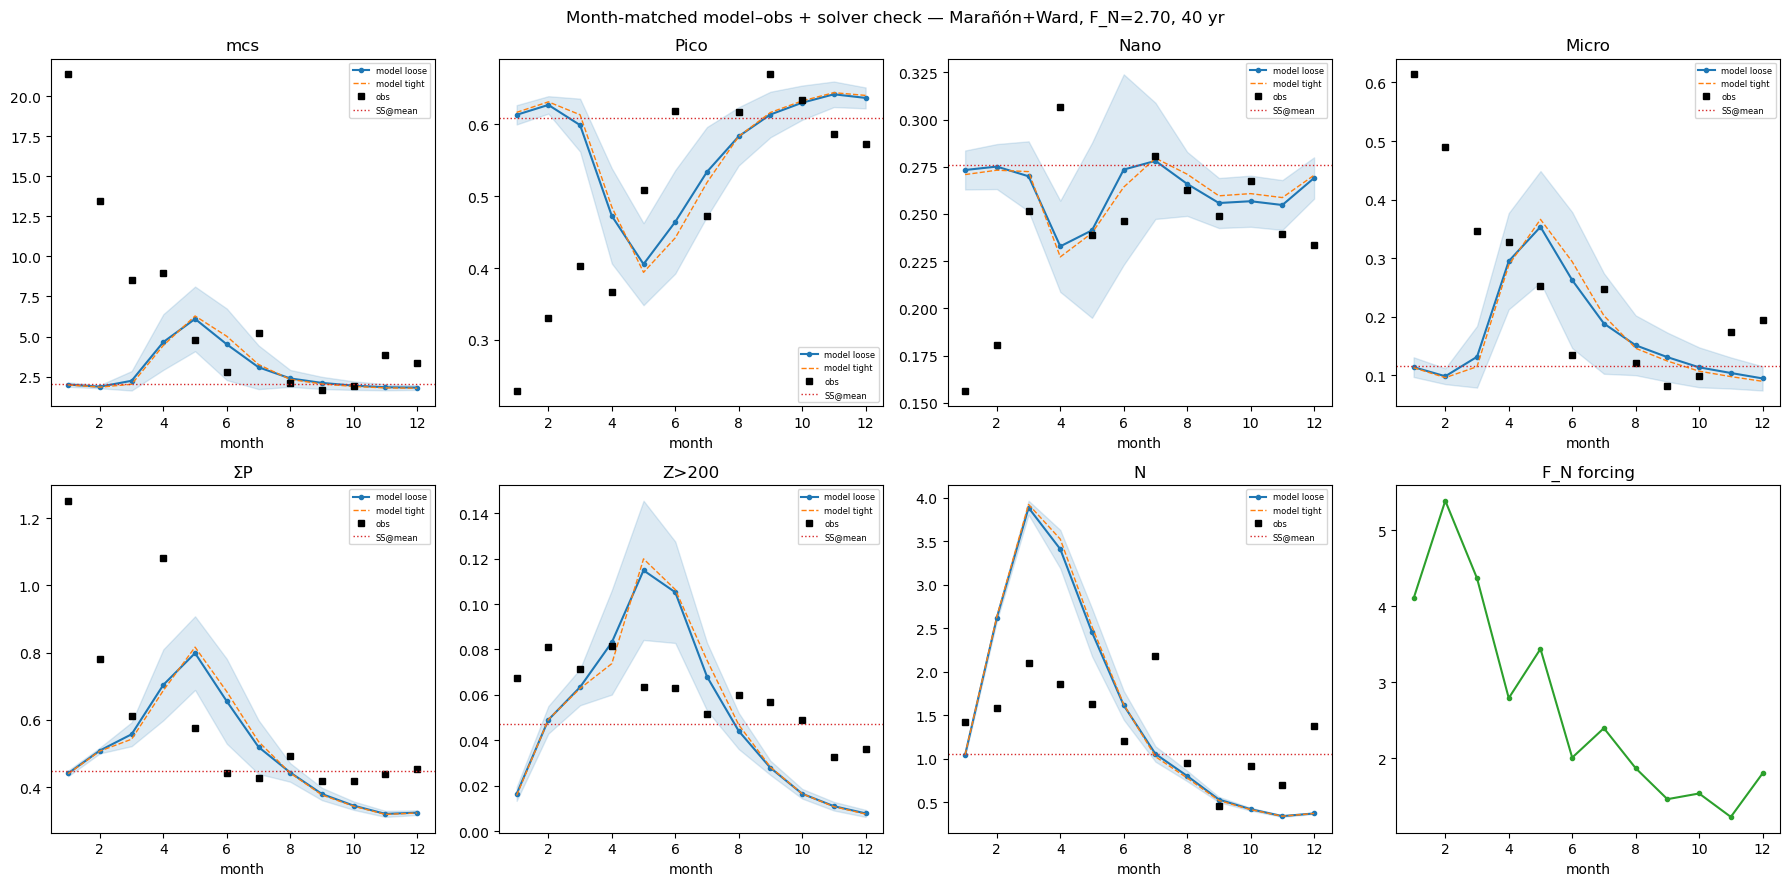

In [12]:
# ── MONTH-MATCHED model–obs comparison + SOLVER CHECK ────────────────────────
import numpy as np, pandas as pd, matplotlib.pyplot as plt, json
import xso, cariaco_obs as co, baseline_r0_setups as brs
import parscan_utils_extended as pue, baseline_r0_seasonal_setups as sss
from baseline_r0_seasonal_comps import _DPM
import importlib
for m in (co, brs, pue): importlib.reload(m)
importlib.reload(sss)

N_YEARS, SPINUP_YEARS = 40, 10
KEYS = ['mcs', 'fpico', 'fnano', 'fmicro', 'sumP', 'Zg200', 'N']
LAB = {'mcs':'mcs','fpico':'Pico','fnano':'Nano','fmicro':'Micro','sumP':'ΣP','Zg200':'Z>200','N':'N'}
geom = np.asarray(pue.CARIACO_PHYTO_BIN_GEOMEANS, float)

# --- obs: per-row metrics -> per-calendar-month climatology (mean + sample count) ---
_, _, _, mdf, _ = co.load_cariaco_targets('all', months='available', agg='mean')
mdf = mdf.copy(); mdf['cal_month'] = pd.to_datetime(mdf['date']).dt.month
fn_clim = (mdf.groupby('cal_month')['FN_mmolN_m2_d'].mean()
              .reindex(range(1,13)).interpolate().bfill().ffill().to_numpy())
Pm = mdf[['pico_mmolN','nano_mmolN','micro_mmolN']].to_numpy(float)
tot = Pm.sum(1); fr = Pm/np.where(tot[:,None]>0, tot[:,None], np.nan)
obs_metric = {'mcs': 10**(fr@np.log10(geom)), 'fpico': fr[:,0], 'fnano': fr[:,1], 'fmicro': fr[:,2],
              'sumP': tot, 'Zg200': mdf['zoo_gt200_mmolN'].to_numpy(float), 'N': mdf['NO3_mmolN'].to_numpy(float)}
cal = mdf['cal_month'].to_numpy()
obs_clim = {k: np.array([np.nanmean(obs_metric[k][cal==m]) if np.isfinite(obs_metric[k][cal==m]).any() else np.nan
                         for m in range(1,13)]) for k in KEYS}
obs_cnt = {k: np.array([int(np.isfinite(obs_metric[k][cal==m]).sum()) for m in range(1,13)]) for k in KEYS}
obs_ann = {k: float(np.nanmean(obs_metric[k])) for k in KEYS}   # obs sampling-weighted mean

# --- construct + run helper ---
esd = brs.phyto_esd
mu_mar = np.where(esd<=5.38, 0.33*esd**0.57, 1.83*esd**-0.45); ks_ward = 0.143*esd**0.81
PAR = dict(mP=0.02, KsZ=0.20, sig=0.20)

def traj(o):
    Pb = o['Phytoplankton__biomass'].transpose('time','phyto').values
    W = pue.compute_sieburth_weights(o['phyto'].values)
    b = np.einsum('kp,tp->tk', W, Pb); f = b/np.clip(b.sum(1,keepdims=True),1e-30,None)
    return dict(t=o['time'].values, mcs=10**(f@np.log10(geom)), fpico=f[:,0], fnano=f[:,1], fmicro=f[:,2],
                sumP=Pb.sum(1), N=o['Nutrient__value'].values,
                Zg200=o['Zooplankton__biomass'].where(o['zoo']>200.,0.).sum('zoo').values)

def run_seasonal(solver_kwargs):
    iv = sss.make_seasonal_input_vars(fn_clim, mu_max=mu_mar, halfsat=ks_ward, mP=PAR['mP'])
    iv['Grazing'] = {**iv['Grazing'], 'KsZ': PAR['KsZ'], 'sigma_log': PAR['sig']}
    st = xso.setup(solver='solve_ivp', model=sss.model_baseline_seasonal,
                   time=np.arange(0., N_YEARS*365.+1., 1.), input_vars=iv,
                   output_vars=set(sss.SLIM_OUTPUT_VARS), solver_kwargs=solver_kwargs)
    return traj(pue.run_single_point(sss.model_baseline_seasonal, st, {}))

LOOSE = {**brs.IVP_SOLVER_KWARGS, 'instability_neg_threshold': -1e-3}
TIGHT = {**brs.IVP_SOLVER_KWARGS, 'atol': 1e-8, 'rtol': 1e-6, 'instability_neg_threshold': -1e-3}
print("running LOOSE (atol 1e-6 / rtol 1e-4) ..."); ML = run_seasonal(LOOSE)
print("running TIGHT (atol 1e-8 / rtol 1e-6) ..."); MT = run_seasonal(TIGHT)

edges = np.cumsum(_DPM)
def analyze(M):
    yr = (M['t']//365).astype(int); mon = np.searchsorted(edges, M['t']%365., side='right')+1
    yearly = {k: np.array([np.nanmean(M[k][yr==y]) for y in range(SPINUP_YEARS, N_YEARS)]) for k in KEYS}
    LRm = {k: float(np.nanmean(yearly[k])) for k in KEYS}
    CV = {k: float(np.nanstd(yearly[k])/np.nanmean(yearly[k])) if np.nanmean(yearly[k]) else np.nan for k in KEYS}
    clim, clim_sd = {}, {}
    for k in KEYS:
        ym = np.full((N_YEARS,12), np.nan)
        for y in range(SPINUP_YEARS, N_YEARS):
            for m in range(1,13):
                s = (yr==y)&(mon==m)
                if s.any(): ym[y,m-1] = np.nanmean(M[k][s])
        clim[k] = np.nanmean(ym[SPINUP_YEARS:], axis=0); clim_sd[k] = np.nanstd(ym[SPINUP_YEARS:], axis=0)
    return dict(LRm=LRm, CV=CV, clim=clim, clim_sd=clim_sd)
AL, AT = analyze(ML), analyze(MT)

FN_bar = float(fn_clim.mean()); da,db,dlo,dhi = sss.DE_COEFFS; ta,tb,tlo,thi = sss.T_COEFFS
ss = traj(pue.run_single_point(brs.model_baseline, brs.setup_baseline_slim, {},
        {'Inflow__FN': FN_bar, 'Inflow__de': float(np.clip(da-db*FN_bar,dlo,dhi)),
         'Temperature__value': float(np.clip(ta-tb*FN_bar,tlo,thi)),
         'Growth__mu_max': mu_mar, 'Growth__halfsat': ks_ward, 'PhytoMortality__rate': PAR['mP'],
         'Grazing__KsZ': PAR['KsZ'], 'Grazing__sigma_log': PAR['sig'], 'Core__solver_kwargs': json.dumps(LOOSE)}))
ssv = {k: float(np.nanmean(ss[k][ss['t']>=ss['t'][-1]-1000])) for k in KEYS}

# --- PRINT 1: solver check ---
print(f"\nSOLVER CHECK — loose vs tight, {N_YEARS} yr (stats yrs {SPINUP_YEARS}-{N_YEARS})")
print(f"{'metric':7}{'LRloose':>9}{'LRtight':>9}{'%diff':>7}{'CVloose':>9}{'CVtight':>9}{'climΔmax':>10}")
for k in KEYS:
    pdiff = 100*(AT['LRm'][k]-AL['LRm'][k])/AL['LRm'][k] if AL['LRm'][k] else np.nan
    cdmax = float(np.nanmax(np.abs(AL['clim'][k]-AT['clim'][k])))
    print(f"{LAB[k]:7}{AL['LRm'][k]:9.3f}{AT['LRm'][k]:9.3f}{pdiff:7.1f}{AL['CV'][k]:9.2f}{AT['CV'][k]:9.2f}{cdmax:10.4f}")

# --- PRINT 2: month-matched fit (naive annual vs sampling-matched vs obs) ---
print(f"\nMONTH-MATCHED model(loose) vs obs   (modMatch = model weighted by obs sampling per month)")
print(f"{'metric':7}{'SS@mean':>9}{'modNaive':>9}{'modMatch':>9}{'obs':>8}{'match/obs':>10}{'corr':>6}{'rmsRel':>8}")
for k in KEYS:
    w = obs_cnt[k].astype(float); ok = np.isfinite(AL['clim'][k]) & (w>0) & np.isfinite(obs_clim[k])
    modM = float(np.sum(AL['clim'][k][ok]*w[ok])/np.sum(w[ok])) if ok.any() else np.nan
    corr = float(np.corrcoef(AL['clim'][k][ok], obs_clim[k][ok])[0,1]) if ok.sum()>=3 else np.nan
    rms = float(np.sqrt(np.nanmean(((AL['clim'][k][ok]-obs_clim[k][ok])/obs_clim[k][ok])**2))) if ok.any() else np.nan
    print(f"{LAB[k]:7}{ssv[k]:9.3f}{AL['LRm'][k]:9.3f}{modM:9.3f}{obs_ann[k]:8.3f}"
          f"{modM/obs_ann[k] if obs_ann[k] else np.nan:10.2f}{corr:6.2f}{rms:8.2f}")

# --- PRINT 3: per-month mcs & Micro ---
print(f"\nPER-MONTH  mcs (loose/tight/obs,n) | Micro (loose/tight/obs,n)")
for m in range(12):
    print(f"  m{m+1:2d}: {AL['clim']['mcs'][m]:5.2f}/{AT['clim']['mcs'][m]:5.2f}/{obs_clim['mcs'][m]:5.2f}(n{obs_cnt['mcs'][m]:2d}) | "
          f"{AL['clim']['fmicro'][m]:.3f}/{AT['clim']['fmicro'][m]:.3f}/{obs_clim['fmicro'][m]:.3f}(n{obs_cnt['fmicro'][m]:2d})")

# --- FIGURE: seasonal cycle — model loose+band, tight, obs ---
mo = np.arange(1,13); fig, ax = plt.subplots(2,4, figsize=(18,9))
for a,k in zip(ax.flat, KEYS):
    a.plot(mo, AL['clim'][k], 'C0-o', ms=3, label='model loose')
    a.fill_between(mo, AL['clim'][k]-AL['clim_sd'][k], AL['clim'][k]+AL['clim_sd'][k], color='C0', alpha=0.15)
    a.plot(mo, AT['clim'][k], 'C1--', lw=1, label='model tight')
    a.plot(mo, obs_clim[k], 'ks', ms=5, label='obs')
    a.axhline(ssv[k], color='C3', ls=':', lw=1, label='SS@mean')
    a.set_title(LAB[k]); a.set_xlabel('month'); a.legend(fontsize=6)
ax.flat[7].plot(mo, fn_clim, 'C2-o', ms=3); ax.flat[7].set_title('F_N forcing'); ax.flat[7].set_xlabel('month')
fig.suptitle(f"Month-matched model–obs + solver check — Marañón+Ward, F_N̄={FN_bar:.2f}, {N_YEARS} yr")
plt.tight_layout(); plt.show()

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_baseline' and setup 'setup_baseline_slim' from 'baseline_r0_setups' with postprocess 'avg_tail_stats'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'baseline_r0_setups' over 16 points using 8 workers...
1D Scan complete. Time taken: 14.75851 seconds.
mean F_N = 2.70   (sinA0 should ≈ SS@mean — machinery sanity)

metric   SS@mean    sinA0    sinA2  obsclim effFN*(sin2) effFN*(obs)
mcs        2.174    2.050    2.976    2.923          nan         nan
Pico       0.597    0.607    0.566    0.567          nan         nan
Nano       0.270    0.275    0.265    0.262          nan         nan
Micro      0.133    0.119    0.169    0.171          nan         nan
ΣP         0.457    0.450    0.502    0.502         3.03        3.03
Z>200      0.047    0.045    0.053    0.052         2.86        2.83
N          1.071    1.052    1.643    1.549         3.21        3.15

re

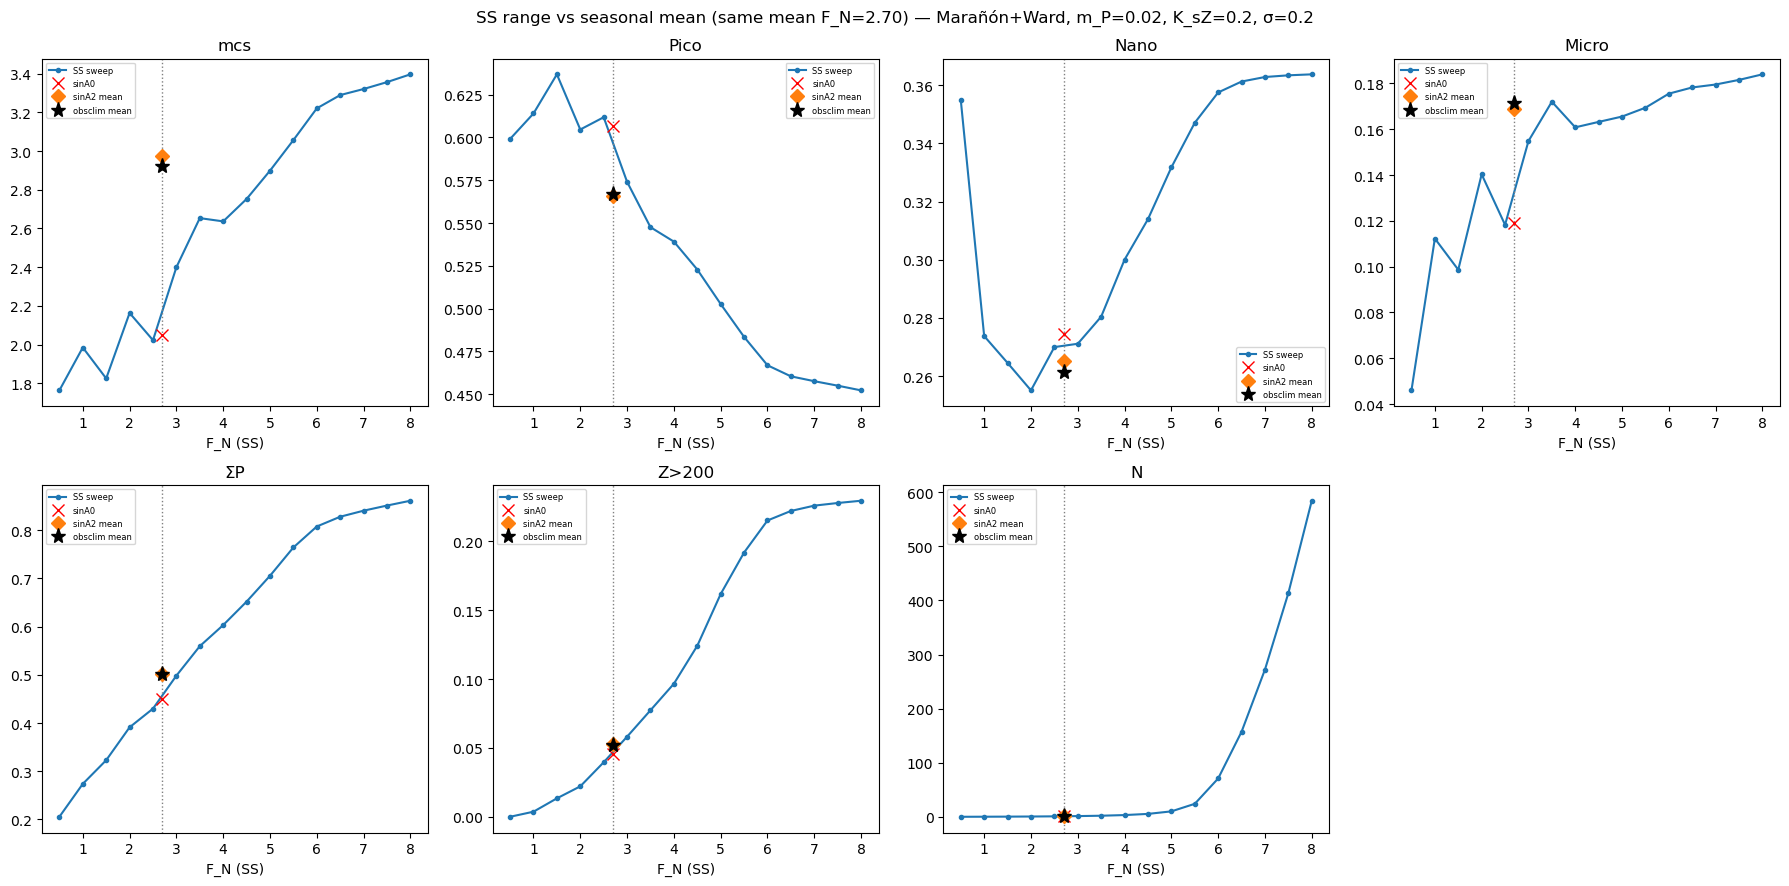

In [13]:
# ── SS-range vs sinusoidal/seasonal forcing — effective-F_N diagnostic ────────
import numpy as np, pandas as pd, matplotlib.pyplot as plt, json
import xso, cariaco_obs as co, baseline_r0_setups as brs
import parscan_utils_extended as pue, baseline_r0_seasonal_setups as sss
from xso.parscans import run_xso_parscan
import importlib
for m in (co, brs, pue): importlib.reload(m)
importlib.reload(sss)

KEYS = ['mcs', 'fpico', 'fnano', 'fmicro', 'sumP', 'Zg200', 'N']
LAB = {'mcs':'mcs','fpico':'Pico','fnano':'Nano','fmicro':'Micro','sumP':'ΣP','Zg200':'Z>200','N':'N'}
geom = np.asarray(pue.CARIACO_PHYTO_BIN_GEOMEANS, float)
esd = brs.phyto_esd
mu_mar = np.where(esd<=5.38, 0.33*esd**0.57, 1.83*esd**-0.45); ks_ward = 0.143*esd**0.81
da,db,dlo,dhi = sss.DE_COEFFS; ta,tb,tlo,thi = sss.T_COEFFS
LOOSE = {**brs.IVP_SOLVER_KWARGS, 'instability_neg_threshold': -1e-3}

# obs climatology (composite means) — same as before
_, _, _, mdf, _ = co.load_cariaco_targets('all', months='available', agg='mean')
mdf = mdf.copy(); mdf['cal_month'] = pd.to_datetime(mdf['date']).dt.month
fn_clim = (mdf.groupby('cal_month')['FN_mmolN_m2_d'].mean().reindex(range(1,13))
              .interpolate().bfill().ffill().to_numpy())
MEAN = float(fn_clim.mean())   # 2.70

def traj(o):
    Pb = o['Phytoplankton__biomass'].transpose('time','phyto').values
    W = pue.compute_sieburth_weights(o['phyto'].values)
    b = np.einsum('kp,tp->tk', W, Pb); f = b/np.clip(b.sum(1,keepdims=True),1e-30,None)
    return dict(t=o['time'].values, mcs=10**(f@np.log10(geom)), fpico=f[:,0], fnano=f[:,1], fmicro=f[:,2],
                sumP=Pb.sum(1), N=o['Nutrient__value'].values,
                Zg200=o['Zooplankton__biomass'].where(o['zoo']>200.,0.).sum('zoo').values)

# --- (1) SS sweep over F_N (gradient-linked d_e/T) ---
FN_SS = np.linspace(0.5, 8.0, 16)
deS = np.clip(da-db*FN_SS, dlo, dhi); TS = np.clip(ta-tb*FN_SS, tlo, thi)
scan = run_xso_parscan(model_file_name='baseline_r0_setups', model_name='model_baseline',
        model_setup_name='setup_baseline_slim', param_name='Inflow__FN', param_values=FN_SS,
        linked_overrides={'Inflow__de': deS, 'Temperature__value': TS},
        fixed_overrides={'Growth__mu_max': mu_mar, 'Growth__halfsat': ks_ward,
                         'PhytoMortality__rate':0.02, 'Grazing__KsZ':0.2, 'Grazing__sigma_log':0.2,
                         'Core__solver_kwargs': json.dumps(LOOSE)},
        postprocess_name='avg_tail_stats', postprocess_kwargs={'avg_window':1000}, processes=8)
m = pue.extract_scan_metrics_1d(scan, 'Inflow__FN', {'Inflow__de': float(np.median(deS))})
ssF = m['axis']
SS = {'mcs': m['mcs'], 'fpico': m['P_pico']/m['sumP'], 'fnano': m['P_nano']/m['sumP'],
      'fmicro': m['P_micro']/m['sumP'], 'sumP': m['sumP'], 'Zg200': m['Z_gt200'], 'N': m['N']}

# --- (2) seasonal runs at the SAME mean: sinusoid A=0, A=2, and the obs climatology ---
def sinus(mean, A, peak_month=2):
    mo = np.arange(1, 13)
    return np.maximum(mean + A*np.cos(2*np.pi*(mo - peak_month)/12.0), 0.0)

def seasonal_lrm(fn_monthly, n_years=30, spinup=8):
    iv = sss.make_seasonal_input_vars(fn_monthly, mu_max=mu_mar, halfsat=ks_ward, mP=0.02)
    iv['Grazing'] = {**iv['Grazing'], 'KsZ':0.2, 'sigma_log':0.2}
    st = xso.setup(solver='solve_ivp', model=sss.model_baseline_seasonal,
                   time=np.arange(0., n_years*365.+1., 1.), input_vars=iv,
                   output_vars=set(sss.SLIM_OUTPUT_VARS), solver_kwargs=LOOSE)
    M = traj(pue.run_single_point(sss.model_baseline_seasonal, st, {}))
    yr = (M['t']//365).astype(int); post = yr >= spinup
    return {k: float(np.nanmean(M[k][post])) for k in KEYS}

runs = {'sinA0': seasonal_lrm(sinus(MEAN, 0.0)),
        'sinA2': seasonal_lrm(sinus(MEAN, 2.0)),
        'obsclim': seasonal_lrm(fn_clim)}

def eff_fn(val, curve, F):
    d = np.diff(curve)
    if np.all(d > 0): return float(np.interp(val, curve, F))
    if np.all(d < 0): return float(np.interp(val, curve[::-1], F[::-1]))
    return np.nan   # non-monotonic SS(F_N) -> no unique effective F_N

ss_at_mean = {k: float(np.interp(MEAN, ssF, SS[k])) for k in KEYS}

# --- PRINTS ---
print(f"mean F_N = {MEAN:.2f}   (sinA0 should ≈ SS@mean — machinery sanity)\n")
print(f"{'metric':7}{'SS@mean':>9}{'sinA0':>9}{'sinA2':>9}{'obsclim':>9}{'effFN*(sin2)':>13}{'effFN*(obs)':>12}")
for k in KEYS:
    ef_s = eff_fn(runs['sinA2'][k], SS[k], ssF); ef_o = eff_fn(runs['obsclim'][k], SS[k], ssF)
    print(f"{LAB[k]:7}{ss_at_mean[k]:9.3f}{runs['sinA0'][k]:9.3f}{runs['sinA2'][k]:9.3f}"
          f"{runs['obsclim'][k]:9.3f}{ef_s:13.2f}{ef_o:12.2f}")
print("\nread: effFN* consistent across metrics => seasonal ≈ SS at an effective higher F_N;"
      "\n      scattered effFN* => seasonal output is genuinely off the SS curve (irreducibly dynamic).")

# --- FIGURE: SS(F_N) curves with seasonal means overlaid at F_N=2.70 ---
fig, ax = plt.subplots(2, 4, figsize=(18, 9))
for a, k in zip(ax.flat, KEYS):
    a.plot(ssF, SS[k], 'C0-o', ms=3, label='SS sweep')
    a.axvline(MEAN, color='grey', ls=':', lw=1)
    a.plot(MEAN, runs['sinA0'][k], 'rx', ms=9, label='sinA0')
    a.plot(MEAN, runs['sinA2'][k], 'D', color='C1', ms=7, label='sinA2 mean')
    a.plot(MEAN, runs['obsclim'][k], 'k*', ms=11, label='obsclim mean')
    a.set_title(LAB[k]); a.set_xlabel('F_N (SS)'); a.legend(fontsize=6)
ax.flat[7].axis('off')
fig.suptitle(f"SS range vs seasonal mean (same mean F_N={MEAN:.2f}) — Marañón+Ward, m_P=0.02, K_sZ=0.2, σ=0.2")
plt.tight_layout(); plt.show()